In [1]:
from cil.io import TIFFStackReader
import numpy as np
import tifffile
import os
os.chdir('/zhome/71/c/146676/Desktop/msaca/main/')
import module_auxiliary as ma
import extended_data as ed
import matplotlib.pyplot as plt

In [51]:
path = '/dtu-compute/msaca/sliceA_xray_pc/compressed_XA_004_/compressed_XA_004_####.tiff'
slices = 2
stride = 1
A = range(1,6001,stride)
path_list = ma.generate_paths(path, A)
ny, nx = np.shape(tifffile.imread(path_list[0]))
data = np.empty((len(A), slices, nx))
for i in range(len(path_list)):
    if (i%1000)==0:
        print(i)
    data[i] = tifffile.imread(path_list[i])[:slices,:]

0
1000
2000
3000
4000
5000


In [52]:
path_dark = '/dtu-compute/msaca/sliceA_xray_pc/compressed_XA_004_/dark/dark.tiff'
path_obeam = '/dtu-compute/msaca/sliceA_xray_pc/compressed_XA_004_/obeam/refHST6000.tiff'

dark = tifffile.imread(path_dark)[:slices,:]
obeam = tifffile.imread(path_obeam)[:slices,:]

data_normalized = np.array(-np.log((data - dark[np.newaxis,:,:])/(obeam[np.newaxis,:,:] - dark[np.newaxis,:,:])),dtype=np.float32)

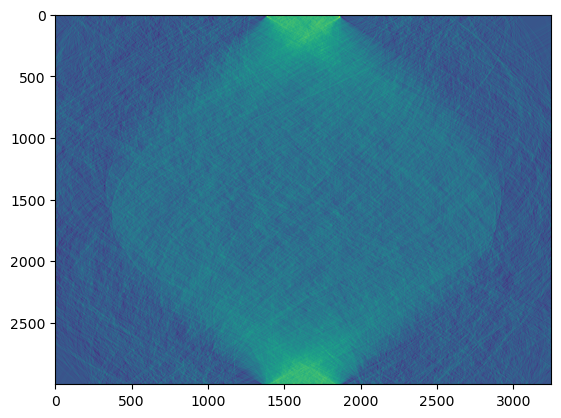

In [53]:
split_row = int(6000/2/stride)
split_col = nx-248
raw_data_180 = ma.rearrange_3d_block_matrix(data_normalized, split_row, split_col)
plt.imshow(raw_data_180[:,0,:], aspect='auto')
plt.show()

In [54]:
from cil.framework import AcquisitionGeometry
angles = np.linspace(0, 180, 3000, endpoint=True, dtype=np.float32)
angles = angles[::stride]
N_pixels = np.shape(raw_data_180)[2]
N_slices = np.shape(raw_data_180)[1]
print(np.shape(raw_data_180))
ag = AcquisitionGeometry.create_Parallel3D(detector_position=[0,N_pixels//2,0])\
                            .set_angles(angles)\
                            .set_panel((N_pixels,N_slices), pixel_size=(1,1))\
                            .set_labels(labels=('angle','vertical','horizontal'))

print(len(angles))
sinograms = ed.ExtendedData()
sinograms.set_data(data = raw_data_180)
sinograms.acquisition_data(geometry=ag)
ig = sinograms.data.geometry.get_ImageGeometry(resolution=1)
sinograms.set_rotation_axis(position = [0,0,0], rotation = [0,0,1])

(3000, 2, 3248)
3000


In [55]:
recon = sinograms.fbp()

In [56]:
from cil.framework import AcquisitionGeometry, AcquisitionData, ImageGeometry, ImageData, BlockDataContainer
from cil.plugins.astra.operators import ProjectionOperator
from cil.optimisation.operators import BlockOperator, GradientOperator, IdentityOperator
from cil.optimisation.utilities import callbacks
from cil.optimisation.algorithms import CGLS, SIRT, GD, FISTA, ISTA, PDHG, SPDHG
from cil.plugins.ccpi_regularisation.functions import FGP_TV

recons = []

for alpha in [10]:
    sinograms.data.reorder('astra')
    A = ProjectionOperator(ig, ag, 'gpu')
    L = IdentityOperator(ig)
    block_operator = BlockOperator(A, alpha*L)

    b = sinograms.data
    zero_data = L.range.allocate(0)
    block_data = BlockDataContainer(b, zero_data)

    initial = ig.allocate(0)
    reconstructor = CGLS(initial=initial, operator=block_operator, data=block_data, update_objective_interval = 5 )

    iteration_history = [10,40]
    iteration_history = [iteration_history] if isinstance(iteration_history,int) else iteration_history
    reconstruction = []
    prev = 0
    for i in range(len(iteration_history)):
        reconstructor.run(iteration_history[i] - prev, verbose=1)
        prev = iteration_history[i]
        reconstruction.append(reconstructor.solution.copy())

    recons.append(reconstruction[0].as_array()[0])
    recons.append(reconstruction[1].as_array()[0])

  0%|          | 0/10 [00:00<?, ?it/s]

 28%|##7       | 11/40 [00:00<?, ?it/s]

In [ ]:

for alpha in [1]:
    sinograms.data.reorder('astra')
    A = ProjectionOperator(ig, ag, 'gpu')
    L = IdentityOperator(ig)
    block_operator = BlockOperator(A, alpha*L)

    b = sinograms.data
    zero_data = L.range.allocate(0)
    block_data = BlockDataContainer(b, zero_data)

    initial = ig.allocate(0)
    b = sinograms.data
    F = LeastSquares(A, b)
    G = alpha*FGP_TV(device='gpu')
    reconstructor = FISTA(f=F, g=G, initial=initial, update_objective_interval = 5)

    iteration_history = [10,20]
    iteration_history = [iteration_history] if isinstance(iteration_history,int) else iteration_history
    reconstruction = []
    prev = 0
    for i in range(len(iteration_history)):
        reconstructor.run(iteration_history[i] - prev, verbose=1)
        prev = iteration_history[i]
        reconstruction.append(reconstructor.solution.copy())

    recons.append(reconstruction[0].as_array()[0])
    recons.append(reconstruction[1].as_array()[0])


  0%|          | 0/10 [00:00<?, ?it/s]

 28%|##7       | 11/40 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

 28%|##7       | 11/40 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

 28%|##7       | 11/40 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

 28%|##7       | 11/40 [00:00<?, ?it/s]

In [ ]:
recons.append(recon.as_array()[0])

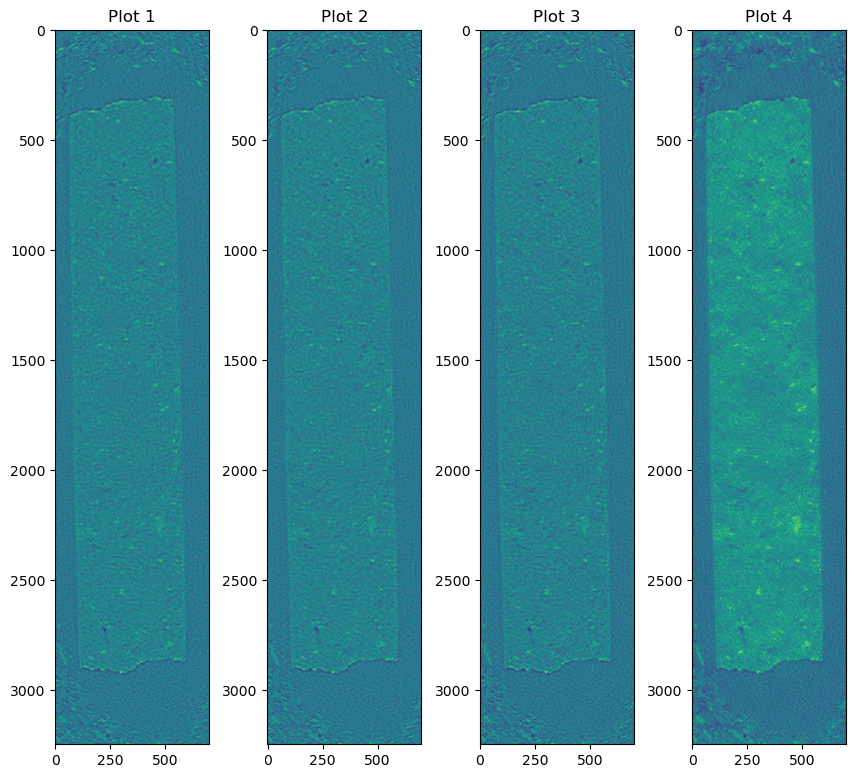

In [ ]:
n_plots = 8
# Create a 1x4 grid for the subplots
fig, axes = plt.subplots(1, n_plots, figsize=(6, 2))

# Loop through the axes and plot on each subplot
for i, ax in enumerate(axes):
    ax.imshow(recons[i][:,1300:2000])  # Example data
    ax.set_title(f'Plot {i+1}')

plt.tight_layout(pad=-20.1) 
plt.show()

In [ ]:
#import SimpleITK as sitk
full_path = '/dtu-compute/msaca/sliceA_xray_pc/estrids_recon/xray_3um_stitch_total.tif'
#full_recon = sitk.ReadImage(full_path)
#full_recon1 = sitk.GetArrayFromImage(full_recon)

In [ ]:
#import SimpleITK as sitk
#full_path = '/dtu-compute/msaca/sliceA_xray_pc/estrids_recon/xray_3um_reslice_itksnap.tif'
#small_recon = sitk.ReadImage(full_path)
#small_recon1 = sitk.GetArrayFromImage(small_recon)

TIFFReadDirectory: Warning, Unknown field with tag 50838 (0xc696) encountered.
TIFFReadDirectory: Warning, Unknown field with tag 50839 (0xc697) encountered.
TIFFReadDirectory: Warning, Unknown field with tag 50838 (0xc696) encountered.
TIFFReadDirectory: Warning, Unknown field with tag 50839 (0xc697) encountered.


In [12]:
full_path = '/dtu-compute/msaca/sliceA_xray_pc/estrids_recon/xray_3um_stitch_total.tif'
data_large = tifffile.imread(full_path)
full_path = '/dtu-compute/msaca/sliceA_xray_pc/estrids_recon/xray_3um_reslice_itksnap.tif'
data_small = tifffile.imread(full_path)

(3985, 3020, 670) float16
(1412, 1392, 280) float32


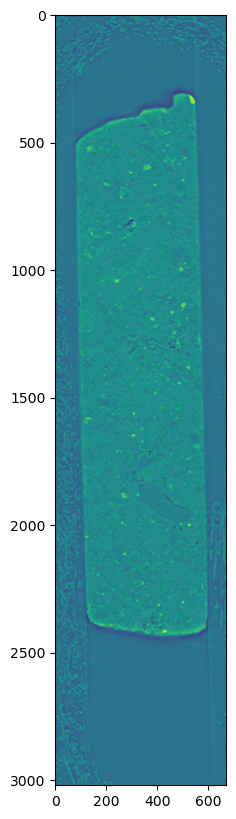

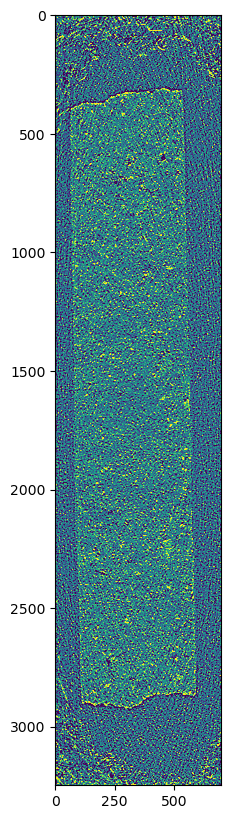

In [25]:
print(np.shape(data_large), data_large.dtype)
print(np.shape(data_small), data_small.dtype)
plt.figure(figsize=(10,10))
plt.imshow(data_large[700,:,:])
plt.show()
plt.figure(figsize=(10,10))
plt.imshow(recon.as_array()[0,:,1300:2000])
plt.clim([-0.001,0.002])
plt.show()

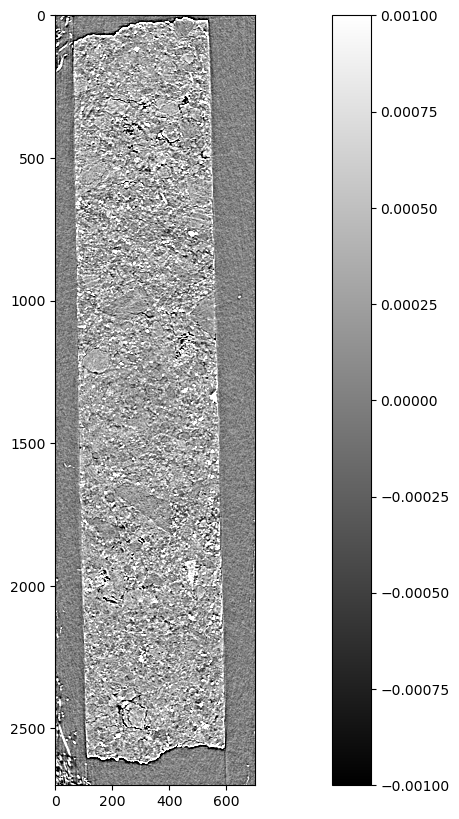

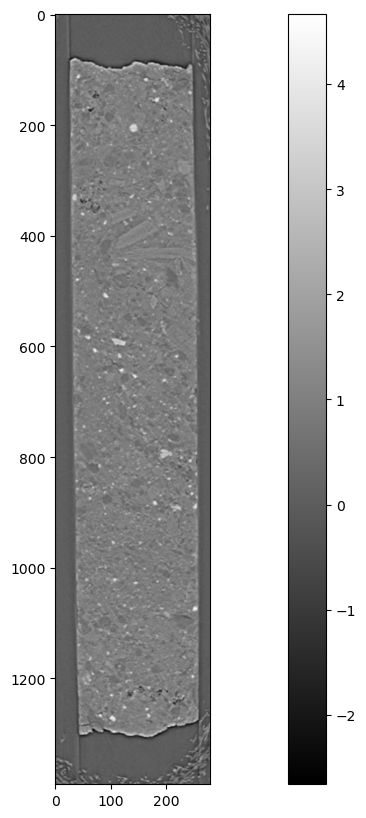

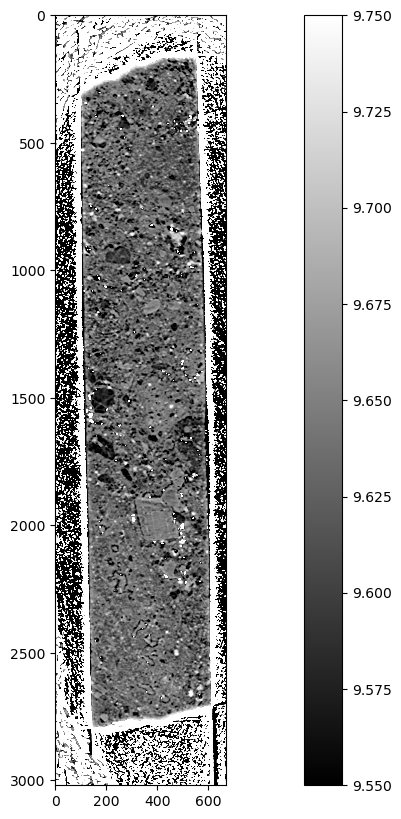

In [ ]:
plt.figure(figsize=(20,10))
plt.imshow(recon.as_array()[0,300:3000,1300:2000], cmap='gray')
plt.clim([-0.001,0.001])
plt.colorbar()
plt.show()
plt.figure(figsize=(20,10))
plt.imshow(small_recon1[600,:,:], cmap='gray')
plt.colorbar()
plt.show()
plt.figure(figsize=(20,10))
plt.imshow(np.log(full_recon1[1800,:,:]), cmap='gray')
plt.clim([9.55,9.75])
plt.colorbar()
plt.show()

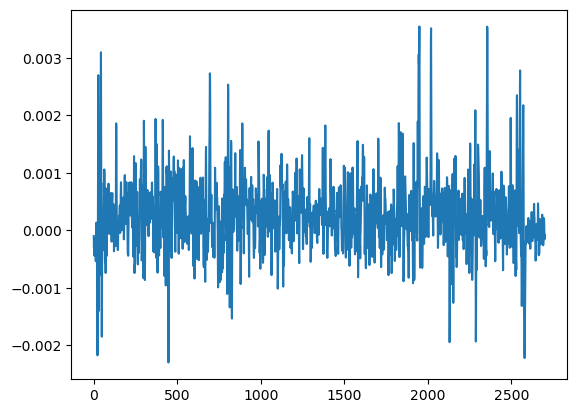

In [52]:
plt.plot(recon.as_array()[0,300:3000,1700])

15082


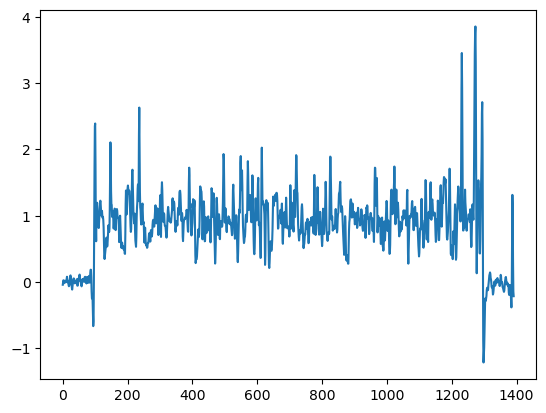

In [64]:
plt.plot(small_recon1[600,:,100])
print(full_recon1[600,2000,100])

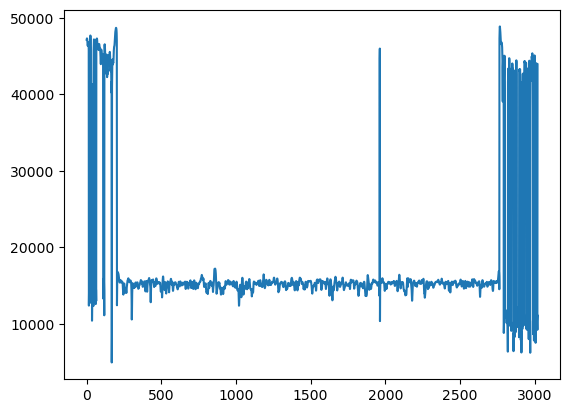

In [55]:
plt.plot(full_recon1[1800,:,300])

In [ ]:
import h5py
#%% Read volume
col = "007"
row = "1216" #0912" # "0456"

path = "/home/ebna/Documents/ESRF_tomo_scans/HA900_3um_mars_rock_"+col+"_pag_db0025_vol/"
filename = "HA900_3um_mars_rock_"+col+"_pag_db0025_vol_"+row+".hdf5"

f = h5py.File(path+filename, "r")
print("Keys: %s" % f.keys())

a_group_key = list(f.keys())[0]
# group1 = list(f[a_group_key])
# group2 = list(f[a_group_key][group1[1]])
# group3 = list(f[a_group_key][group1[1]][group2[3]])

recon_test = f[a_group_key]['reconstruction']['results'] ['data']